# omnisea — one query, eight datasets, one defensible model

Bamfield Marine Sciences Centre sits on Barkley Sound, on the exposed west coast of Vancouver
Island. Within 30 km of it a federal tide gauge, several lighthouse climate records, four river
gauge collections and a glider track served from an ERDDAP all publish something — eight
datasets from three organizations, each with its own format, time convention and units, plus an
Ocean Networks Canada cabled observatory for anyone holding a token.

This notebook does the whole job: find what exists, pull it, join it to a field sheet, prune the
redundancy, fit a model, and produce the citation. Every number below came from a live API when
this was last executed.

**The thing to watch for** is not that it works — it is the places where a naive version of this
would have been *quietly wrong*, and what omnisea does about each one. Those are called out as
you go.


In [1]:
import warnings

import numpy as np
import pandas as pd

import omnisea

warnings.simplefilter("ignore")
pd.set_option("display.width", 120)

# A Site is the location type: coordinates, a search radius, and the name you know it by.
# That name travels with the results, so what comes back joins to your own records.
BAMFIELD = omnisea.Site(48.8353, -125.1358, "Bamfield", radius_km=30)
WEEK = ("2024-07-01", "2024-07-08")

print(f"omnisea {omnisea.__version__}")
print(f"{len(omnisea.sources())} sources across {len(omnisea.providers())} organizations:")
print("  " + ", ".join(omnisea.providers()))

omnisea 0.1.0
42 sources across 18 organizations:
  cioos, cioos_atlantic, cioos_pacific, cioos_slgo, coastwatch, coastwatch_west, dfo, eccc, erddap, glider_dac, hakai, ioos_sensors, noaa_coops, nwem, onc, osmc, salishseacast, usgs


## 1. Discover — look before you download

`discover()` asks every registered source what it has, and returns a printable catalogue with a
row estimate. **Nothing has been downloaded yet.**

That separation is not politeness. ECCC's `climate-hourly` collection reports **276 million
rows** unfiltered; the estimate is how you find that out before the request rather than after.

In [2]:
catalog = omnisea.discover(sites=BAMFIELD, time=WEEK)
catalog

source,station_id,name,distance_km,n_rows_est,variables
osmc_tabledap,drifter_6hour_qc,Global Drifter Program - 6 Hour Interpolated QC Drifter Data,0.00,1008,sea_surface_subskin_temperature
hakai_griddap,sentinel_3A_POLYMER,Daily satellite (Sentinel 3A and 3B) chlorophyll and suspen…,0.00,152384217,mass_concentration_of_chlorophyll_a_in_sea_water
hakai_griddap,sentinel_3A_POLYMER_8Day,Sentinel 3A and 3B Chlorophyll and Suspended Matter Concent…,0.00,90376998,mass_concentration_of_chlorophyll_a_in_sea_water
osmc_tabledap,ArgoFloats,Argo Float Measurements,0.00,1008,"sea_water_pressure, sea_water_temperature, sea_water_practi…"
osmc_tabledap,cchdo_bottle,CCHDO GO SHIP bottle data,0.00,1008,"sea_water_pressure, sea_water_temperature, sea_water_practi…"
cioos_pacific_tabledap,IOS_BOT_Profiles,IOS Rosette Bottle Data,0.00,1008,"sea_water_pressure, sea_water_temperature, sea_water_practi…"
cioos_pacific_tabledap,IOS_CUR_Moorings,IOS Moored Current Meter Data,0.00,1008,"sea_water_pressure, instrument_depth, sea_water_temperature…"
cioos_pacific_tabledap,IOS_CTD_Moorings,IOS Moored CTD Data,0.00,336,"sea_water_pressure, instrument_depth, sea_water_temperature…"
osmc_tabledap,cchdo_ctd,CCHDO GO SHIP ctd data,0.00,1008,"sea_water_pressure, sea_water_temperature, sea_water_practi…"
cioos_pacific_tabledap,dfo-eva035-20251103_delayed_erddap,dfo-eva035-20180712T1451,0.00,1008,"platform_orientation, platform_pitch_angle, platform_roll_a…"


Eight sources answered, from three organizations — 37 stations in all. `catalog.frame` is the full twelve-column table if you want to filter
programmatically; the printed view is trimmed to the columns the decision actually turns on.

Note what is *absent*: the realtime collections. They keep a rolling ~30-day window, so a 2024
query cannot be served — and rather than returning nothing (which reads as *there is no station
here*), they say why.

In [3]:
for source, note in catalog.notes.items():
    print(f"{source}:\n  {note}\n")

eccc_ahccd_annual:
  covers 1840-01-01 to 2020-12-31; the requested window starts 2024-07-01, after the last data this collection publishes

eccc_ahccd_monthly:
  covers 1840-01-01 to 2020-12-31; the requested window starts 2024-07-01, after the last data this collection publishes

eccc_ahccd_seasonal:
  covers 1840-01-01 to 2020-12-31; the requested window starts 2024-07-01, after the last data this collection publishes

eccc_hydrometric:
  holds only the last ~30 days (back to 2026-07-28); the requested window ends 2024-07-08 and is entirely outside it

eccc_swob:
  holds only the last ~30 days (back to 2026-07-28); the requested window ends 2024-07-08 and is entirely outside it

eccc_swob_marine:
  holds only the last ~30 days (back to 2026-07-28); the requested window ends 2024-07-08 and is entirely outside it

salishseacast_tabledap:
  nothing matched, but 5 tabledap dataset(s) on https://salishsea.eos.ubc.ca/erddap declare no geospatial extent, so no area query can reach them — t

## 2. Narrow it down

`filter()` returns a new catalogue; the original is untouched.

In [4]:
print("nearest station per source:")
print(catalog.filter(nearest=1).describe().to_string(index=False))

print()
print(f"  within 10 km ....... {len(catalog.filter(max_distance_km=10)):2d} stations")
print(f"  tide gauges only ... {len(catalog.filter(source='dfo_tides')):2d} stations")
print(f"  all ECCC datasets .. {len(catalog.filter(provider='eccc')):2d} stations")
print(f"  air temperature .... {len(catalog.filter(variables='air_temperature')):2d} stations")

nearest station per source:
                       source                         station_id                               name  distance_km  n_rows_est                          variables
       cioos_pacific_tabledap                   IOS_BOT_Profiles            IOS Rosette Bottle Data         0.00        1008 sea_water_pressure, sea_water_tem…
                hakai_griddap                sentinel_3A_POLYMER Daily satellite (Sentinel 3A and …         0.00   152384217 mass_concentration_of_chlorophyll…
                osmc_tabledap                         ArgoFloats            Argo Float Measurements         0.00        1008 sea_water_pressure, sea_water_tem…
                    dfo_tides                              08545                           Bamfield         0.08         700 water_surface_height_above_refere…
         eccc_climate_monthly                            1030610                      BAMFIELD WEST         1.06           1 air_temperature, days_with_valid_…
      eccc_h

## 3. Fetch

We take the tide gauge and the nearest daily climate record. `describe()` is the "did I get what
I asked for?" view.

In [5]:
tree = catalog.filter(source=["dfo_tides", "eccc_climate_daily"], nearest=1).fetch()
omnisea.describe(tree)

,node,station_name,n_time,start,end,variables
0,/in_situ/tides/08545,Bamfield,672,2024-07-01 00:00,2024-07-08 00:00,"water_surface_height_above_reference_datum, r…"
1,/predictions/tides_hilo/08545,Bamfield,27,2024-07-01 03:33,2024-07-07 22:03,water_surface_height_above_reference_datum_at…
2,/in_situ/weather_daily/1031316,CAPE BEALE LIGHT,8,2024-07-01 00:00,2024-07-08 00:00,"air_temperature, air_temperature_min, air_tem…"


Three nodes from two requests. Look at the paths:

- `/in_situ/tides/08545` — what the gauge **measured**
- `/predictions/tides_hilo/08545` — what the harmonic model **predicts**
- `/in_situ/weather_daily/1031316` — the lighthouse climate record

**Observations and predictions never share a node.** In a flat table they are indistinguishable
columns of water level; they are not remotely the same thing, and the tree makes that structural
rather than a matter of remembering.

In [6]:
tree

<xarray.DataTree>
Group: /
│   Attributes: (12/20)
│       query_start:               2024-07-01T00:00:00+00:00
│       query_end:                 2024-07-08T00:00:00+00:00
│       query_bbox:                [-125.54568384357654, 48.56550389088264, -124....
│       query_site_names:          ["Bamfield"]
│       query_site_lats:           [48.8353]
│       query_site_lons:           [-125.1358]
│       ...                        ...
│       n_empty_series_dropped:    0
│       omnisea_fetched_stations:  2
│       omnisea_group_by_site:     0
│       omnisea_max_rows:          2000000
│       omnisea_on_error:          raise
│       omnisea_source_notes:      eccc_ahccd_annual: covers 1840-01-01 to 2020-1...
├── Group: /in_situ
│   ├── Group: /in_situ/tides
│   │   └── Group: /in_situ/tides/08545
│   │           Dimensions:                                        (time: 672)
│   │           Coordinates:
│   │             * time                                           (time) datetime64[ns] 5kB ...
│   │               latitude                                       float64 8B 48.84
│   │               longitude                                      float64 8B -125.1
│   │               station_id                                     <U5 20B '08545'
│   │               station_name                                   <U8 32B 'Bamfield'
│   │               site                                           <U8 32B 'Bamfield'
│   │           Data variables:
│   │               water_surface_height_above_reference_datum     (time) float64 5kB 2.014 ....
│   │               water_surface_height_above_reference_datum_qc  (time) object 5kB '1' ... '1'
│   │               reviewed                                       (time) int8 672B 1 1 ... 1 1
│   │           Attributes: (12/22)
│   │               Conventions:            CF-1.10
│   │               featureType:            timeSeries
│   │               source_name:            dfo_tides
│   │               institution:            Fisheries and Oceans Canada / Canadian Hydrograph...
│   │               license:                Fisheries and Oceans Canada — Open Government Lic...
│   │               references:             https://open.canada.ca/en/open-government-licence...
│   │               ...                     ...
│   │               summary:                Observed water level
│   │               datum_offset_CGVD2013:  -1.83
│   │               datum_offset_CGVD28:    -2.05
│   │               datum_offset_comment:   Offsets convert chart datum to the named vertical...
│   │               resolution:             FIFTEEN_MINUTES
│   │               distance_from_site_km:  0.079
│   └── Group: /in_situ/weather_daily
│       └── Group: /in_situ/weather_daily/1031316
│               Dimensions:                 (time: 8)
│               Coordinates:
│                 * time                    (time) datetime64[ns] 64B 2024-07-01 ... 2024-07-08
│                   latitude                float64 8B 48.79
│                   longitude               float64 8B -125.2
│                   station_id              <U7 28B '1031316'
│                   station_name            <U16 64B 'CAPE BEALE LIGHT'
│                   site                    <U8 32B 'Bamfield'
│               Data variables:
│                   air_temperature         (time) float64 64B 14.0 14.0 13.8 ... 14.8 17.8 15.8
│                   air_temperature_min     (time) float64 64B 11.5 11.0 11.0 ... 4.0 13.5 11.5
│                   air_temperature_max     (time) float64 64B 16.5 17.0 16.5 ... 25.5 22.0 20.0
│                   precipitation_amount    (time) float64 64B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
│                   rainfall_amount         (time) float64 64B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
│                   snowfall_amount         (time) float64 64B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
│                   surface_snow_thickness  (time) float64 64B 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
│                   cooling_degree_days     (

## 4. Provenance travels with the data

Every node carries who published it, under what licence, and the exact URL it was read from.

In [7]:
tides = tree["/in_situ/tides/08545"].dataset
for key in ("institution", "license", "datum", "datum_offset_CGVD2013", "source_url"):
    print(f"{key:24s} {tides.attrs.get(key)}")

institution              Fisheries and Oceans Canada / Canadian Hydrographic Service
license                  Fisheries and Oceans Canada — Open Government Licence – Canada
datum                    chart datum (CD)
datum_offset_CGVD2013    -1.83
source_url               https://api-iwls.dfo-mpo.gc.ca/api/v1/stations/5cebf1e23d0f4a073c4bc062/data?time-series-code=wlo


## 5. Nothing is silently dropped, and nothing is silently rescaled

`fields()` is the honest inventory of a result — not what omnisea *can* name, but what this
particular fetch actually returned.

In [8]:
inventory = omnisea.fields(tree)
print(inventory["kind"].value_counts().to_string())
print()
inventory[["variable", "units", "kind", "source"]].drop_duplicates("variable").head(12)

kind
CF         11
carried     2
qc flag     2



,variable,units,kind,source
0,water_surface_height_above_reference_datum,m,CF,dfo_tides
1,reviewed,,carried,dfo_tides
2,water_surface_height_above_reference_datum_qc,,qc flag,dfo_tides
3,air_temperature,degC,CF,eccc_climate_daily
4,air_temperature_max,degC,CF,eccc_climate_daily
5,air_temperature_min,degC,CF,eccc_climate_daily
6,cooling_degree_days,degC day,CF,eccc_climate_daily
7,heating_degree_days,degC day,CF,eccc_climate_daily
8,precipitation_amount,mm,CF,eccc_climate_daily
9,rainfall_amount,mm,CF,eccc_climate_daily


`CF` means omnisea gave it a canonical name. **`carried` means it had no CF equivalent and was
kept anyway**, under the provider's own name — a realtime weather station adds dozens of these
(battery voltage, solar panel current). Dropping them would make omnisea lossy, which defeats
the point of a unified client.

Units say what the values *actually are*. Conversion is opt-in, because silently turning 15 °C
into 288.15 K makes a scientist distrust their own data at a glance:

In [9]:
air = tree["/in_situ/weather_daily/1031316"].dataset["air_temperature"]
print(f"units       {air.attrs['units']}")
print(f"cf_units    {air.attrs.get('cf_units')}")
print(f"note        {air.attrs.get('note')}")

converted = catalog.filter(source="eccc_climate_daily", nearest=1).fetch(to_cf_units=True)
kelvin = converted["/in_situ/weather_daily/1031316"].dataset["air_temperature"]
print(f"\nto_cf_units=True -> {float(kelvin[0]):.2f} {kelvin.attrs['units']}"
      f"   (was {float(air[0]):.2f} {air.attrs['units']})")

units       degC
cf_units    K
note        values are in provider units (degC); pass to_cf_units=True for K

to_cf_units=True -> 287.15 K   (was 14.00 degC)


Encoding **repairs** are a different thing and are always applied. ECCC publishes wind direction
in *tens of degrees* — a raw `25` means 250°. That is a storage encoding, not a unit choice, and
leaving it raw would be simply wrong.

## 6. Does it actually behave like the ocean?

Parsing correctly and being *right* are different claims. Two independently fetched series — the
observed water level and the predicted high/low events — should agree if the times, the units and
the datum are all correct.

In [10]:
wlo = tides["water_surface_height_above_reference_datum"].to_series()
hilo = tree["/predictions/tides_hilo/08545"].dataset[
    "water_surface_height_above_reference_datum_at_extremum"].to_series()

values = wlo.to_numpy()
is_peak = (values[1:-1] > values[:-2]) & (values[1:-1] >= values[2:])
days = (wlo.index[-1] - wlo.index[0]) / pd.Timedelta(days=1)

interpolated = wlo.reindex(wlo.index.union(hilo.index)).interpolate().reindex(hilo.index)
print(f"observed range   {values.min():.2f} to {values.max():.2f} m above chart datum")
print(f"highs per day    {is_peak.sum() / days:.2f}   (a semidiurnal coast expects ~2)")
print(f"agreement        mean |predicted - observed| = {(interpolated - hilo).abs().mean():.3f} m,"
      f"  r = {interpolated.corr(hilo):.4f}")

observed range   0.07 to 3.40 m above chart datum
highs per day    2.14   (a semidiurnal coast expects ~2)
agreement        mean |predicted - observed| = 0.060 m,  r = 0.9994


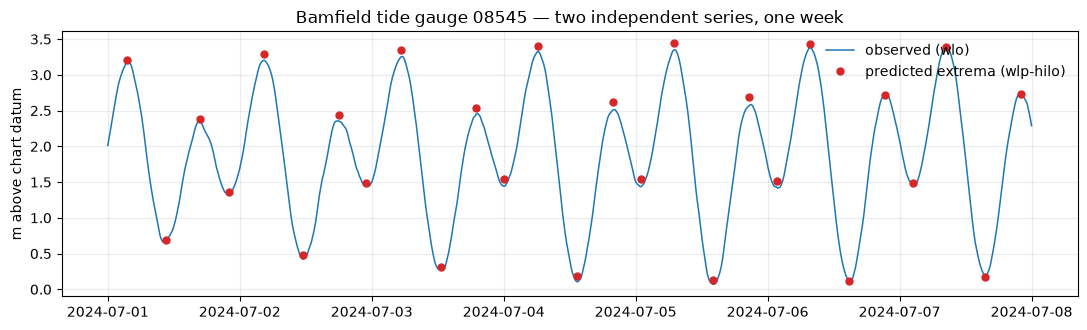

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(wlo.index, wlo.to_numpy(), lw=1.1, color="#1f77b4", label="observed (wlo)")
ax.plot(hilo.index, hilo.to_numpy(), "o", ms=5, color="#d62728",
        label="predicted extrema (wlp-hilo)")
ax.set_ylabel("m above chart datum")
ax.set_title("Bamfield tide gauge 08545 — two independent series, one week")
ax.legend(loc="upper right", frameon=False)
ax.grid(alpha=0.25)
fig.tight_layout()

The red dots sit on the peaks and troughs of the blue line. **That is the real end-to-end check**
— it means the timestamps, the units and the vertical datum are all right, not merely parseable.
The network test suite asserts it on every run.

## 7. Many locations at once

Hand omnisea a list of places — `Site` objects, `(lat, lon, name)` tuples, dicts, or a DataFrame
with `lat`/`lon` columns, so a CSV of moorings you already keep works without reshaping.

In [12]:
sites = [
    omnisea.Site(48.8353, -125.1358, "Bamfield",   radius_km=15),
    omnisea.Site(49.1530, -125.9066, "Tofino",     radius_km=15),
    omnisea.Site(48.4204, -123.3656, "Victoria",   radius_km=15),
    omnisea.Site(47.5000, -128.5000, "Open ocean", radius_km=15),   # deliberately empty
]

multi = omnisea.positions(sites, time=WEEK, providers="dfo_tides", nearest=1)
omnisea.coverage(multi)

,site,n_nodes,n_time,providers,has_data
0,Bamfield,2,699,dfo,True
1,Tofino,2,700,dfo,True
2,Victoria,2,691,dfo,True
3,Open ocean,0,0,,False


**Every site you asked for gets a row, including the one that found nothing.** With a long list
of locations the gaps are the result you most need to see, and inferring them from an absence is
exactly how they get missed.

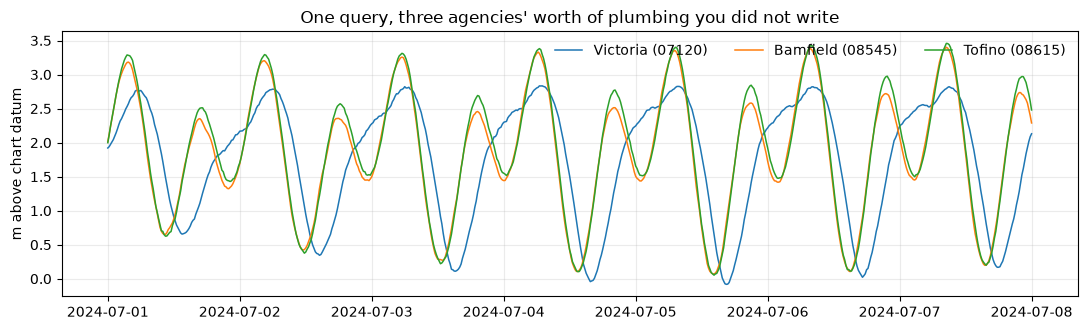

In [13]:
fig, ax = plt.subplots(figsize=(11, 3.4))
for path, ds in omnisea.tree.data_nodes(multi):
    if "water_surface_height_above_reference_datum" not in ds.data_vars:
        continue
    series = ds["water_surface_height_above_reference_datum"].to_series()
    ax.plot(series.index, series.to_numpy(), lw=1.1,
            label=f"{omnisea.tree.scalar_coord(ds, 'site')} ({ds.station_id.item()})")
ax.set_ylabel("m above chart datum")
ax.set_title("One query, three agencies' worth of plumbing you did not write")
ax.legend(loc="upper right", frameon=False, ncols=3)
ax.grid(alpha=0.25)
fig.tight_layout()

Bamfield and Tofino track each other closely — both open Pacific coast. Victoria, inside the
Strait of Juan de Fuca, shows a markedly stronger diurnal inequality: the two daily highs differ
much more than they do outside.

## 8. A source that needs a credential

Ocean Networks Canada runs cabled observatories off both coasts — 1,992 locations, 219 measured
properties. It is the one built-in source needing an API token (free, from
[data.oceannetworks.ca](https://data.oceannetworks.ca) → Profile → Web Services API).

Set `ONC_TOKEN` in your environment, or pass `onc_token=`. **Your token never reaches anything
omnisea writes down** — not the logs, not error messages, not the `source_url` recorded on each
node and written into netCDF files people share.

In [14]:
import os

if os.environ.get("ONC_TOKEN"):
    onc = omnisea.fetch(lat=48.8145, lon=-125.2825, radius_km=6, time=("2024-07-01", "2024-07-02"),
                        providers="onc_scalardata", onc_device_categories="CTD")
    display(omnisea.describe(onc))
    node = next(n for n in onc.subtree if n.dataset.data_vars)
    print("ONC returns its own citation, with a resolvable DOI:")
    print(" ", node.dataset.attrs["citation"][:110], "...")
    print(" ", "https://doi.org/" + node.dataset.attrs["doi"])
    print("\n  source_url (no token in it):", node.dataset.attrs["source_url"])
else:
    print("No ONC_TOKEN set — skipping. Every other source in this notebook needs no credential.")

No ONC_TOKEN set — skipping. Every other source in this notebook needs no credential.


## 9. Bring your own data

Here is a field sheet: a few chlorophyll grab samples a day over the week, at irregular daylight hours,
the way sampling actually happens.

**One thing matters before we join anything.** A field sheet is kept in *local* time. Reading
those stamps as UTC shifts every join by the offset — on a tide series that is metres, and
nothing about the resulting numbers looks wrong. So we localize them, and omnisea warns if you
forget.

In [15]:
rng = np.random.default_rng(11)

days = pd.date_range("2024-07-01", periods=7, freq="D")
stamps = sorted(
    day + pd.Timedelta(hours=float(h))
    for day in days
    for h in rng.uniform(7.5, 18.5, size=rng.integers(4, 7))
)
# Pacific local time, made explicit. Drop the tz_localize and omnisea will warn you.
field_times = pd.DatetimeIndex(stamps).tz_localize("America/Vancouver")

print(f"{len(field_times)} samples, {field_times[0]:%Y-%m-%d %H:%M %Z} "
      f"to {field_times[-1]:%Y-%m-%d %H:%M %Z}")
field_times[:4]

33 samples, 2024-07-01 07:48 PDT to 2024-07-07 17:21 PDT


DatetimeIndex(['2024-07-01 07:48:56.084731529-07:00', '2024-07-01 09:07:37.872949267-07:00',
               '2024-07-01 12:59:31.403352628-07:00', '2024-07-01 14:06:59.334961884-07:00'],
              dtype='datetime64[ns, America/Vancouver]', freq=None)

### The synthetic response, built *independently* of the join

The chlorophyll values are invented — this is a test of the pipeline, not oceanography. But how
they are invented matters.

We build them from the **raw node series**, interpolated with plain pandas at the sample times.
That is deliberately a different code path from `align()`. If we generated the response from
`align()`'s own output and then refit on `align()`'s output, any systematic join error would
appear identically on both sides and cancel exactly — the recovery would look perfect while the
join was hours out. Going around the join to build the truth is what makes the recovery below an
actual test of it.

In [16]:
# Independent path: raw node data -> pandas interpolation -> synthetic response.
naive = field_times.tz_convert("UTC").tz_localize(None)

tide_raw = tides["water_surface_height_above_reference_datum"].to_series()
tide_at_samples = (tide_raw.reindex(tide_raw.index.union(naive))
                   .interpolate(method="time").reindex(naive).to_numpy())

daily = tree["/in_situ/weather_daily/1031316"].dataset["air_temperature_max"].to_series()
# The lighthouse record is labelled by LOCAL calendar date, so the value for a sample is the
# one for the local day it was taken on. We look that up directly here.
tmax_at_samples = daily.reindex(
    pd.DatetimeIndex(field_times.tz_convert("America/Vancouver").normalize().tz_localize(None))
).to_numpy()

TRUE = {"intercept": 6.00, "tide": -0.45, "tmax": 0.30, "hour_sin": 0.60}
hour_sin = np.sin(2 * np.pi * (field_times.hour.to_numpy() - 9) / 24)

chl = (TRUE["intercept"]
       + TRUE["tide"] * tide_at_samples
       + TRUE["tmax"] * tmax_at_samples
       + TRUE["hour_sin"] * hour_sin
       + rng.normal(0, 0.15, len(field_times)))

field_sheet = pd.DataFrame({"time": field_times, "chlorophyll_ug_L": chl.round(2)})
field_sheet.head()

,time,chlorophyll_ug_L
0,2024-07-01 07:48:56.084731529-07:00,9.93
1,2024-07-01 09:07:37.872949267-07:00,9.88
2,2024-07-01 12:59:31.403352628-07:00,10.51
3,2024-07-01 14:06:59.334961884-07:00,10.96
4,2024-07-02 08:16:28.654815706-07:00,10.25


### Join the environment onto the sample times

One call. Every source lines up on *your* timestamps, and your own columns come through — so `y`
and `X` arrive in one table.

In [17]:
X = omnisea.align(tree, on=field_sheet, tolerance="30min")
print(f"{X.shape[0]} rows x {X.shape[1]} columns")
X[["chlorophyll_ug_L", "water_surface_height_above_reference_datum",
   "air_temperature_max", "precipitation_amount"]].head()

33 rows x 14 columns


,chlorophyll_ug_L,water_surface_height_above_reference_datum,air_temperature_max,precipitation_amount
time,,,,
2024-07-01 14:48:56.084731529,9.93,1.919,16.5,0.0
2024-07-01 16:07:37.872949267,9.88,2.324,16.5,0.0
2024-07-01 19:59:31.403352628,10.51,1.636,16.5,0.0
2024-07-01 21:06:59.334961884,10.96,1.404,16.5,0.0
2024-07-02 15:16:28.654815706,10.25,1.616,17.0,0.0


### How each column got there

This is the part you need in a methods section, and it is derived from the CF metadata each
provider published rather than guessed.

In [18]:
audit = pd.DataFrame({
    "how it was joined": pd.Series(X.attrs["omnisea_aggregation"]),
    "units": pd.Series(X.attrs["omnisea_units"]).fillna(""),
})
with pd.option_context("display.max_colwidth", 200, "display.width", 200):
    print(audit.head(10).to_string())

                                                                                                             how it was joined     units
air_temperature            backward within its own 1d interval (33/33 matched), read in station-local time (America/Vancouver)      degC
air_temperature_max        backward within its own 1d interval (33/33 matched), read in station-local time (America/Vancouver)      degC
air_temperature_min        backward within its own 1d interval (33/33 matched), read in station-local time (America/Vancouver)      degC
cooling_degree_days        backward within its own 1d interval (33/33 matched), read in station-local time (America/Vancouver)  degC day
heating_degree_days        backward within its own 1d interval (33/33 matched), read in station-local time (America/Vancouver)  degC day
precipitation_amount       backward within its own 1d interval (33/33 matched), read in station-local time (America/Vancouver)        mm
rainfall_amount            backward withi

Two things worth reading closely.

**`read in station-local time (America/Vancouver)`** on the daily columns. The lighthouse
summaries are labelled by *local* calendar date and stamped at 00:00Z. A late-afternoon Pacific
sample is the next day in UTC — so a naive backward match would hand it **tomorrow's** rain and
temperature, weather that had not yet happened, systematically, for every afternoon sample.
omnisea reads those stamps in the station's own zone, daylight saving included, and names the
zone it used. The same correction applies to `align(freq=...)`, so the two paths cannot
disagree.

**The interval distinction.** A daily total matches *backwards within its own interval* — the
value for the day containing your sample. An instantaneous tide height matches to the nearest
reading within `tolerance`. Without that distinction a 30-minute tolerance against a value
stamped at midnight silently returns a column of `NaN`.

## 10. See the redundancy before you model

A matrix assembled from many sources is collinear by construction. `correlations()` shows every
pair that moves together, with `n` — the overlapping samples each correlation was computed on,
because an r of 1.0 over three points is noise wearing a convincing costume.

In [19]:
omnisea.correlations(X, threshold=0.75)

,feature_a,feature_b,r,n
0,air_temperature,heating_degree_days,-1.00000,33
1,chlorophyll_ug_L,air_temperature_max,0.96195,33


Rows naming `chlorophyll_ug_L` are the response moving with its drivers — that is the model's
*signal*. `drop_correlated()` ignores those pairs entirely: columns you carried through
`align(on=...)` are never dropped and never cause a drop.

Among the **features**, `heating_degree_days` is *derived from* mean temperature (r = −1.000):
a true duplicate, and the one thing here with a right answer. Lower the threshold and softer
pairs appear — daily max against daily min, say, which is a real anti-correlation this particular
week rather than a duplication, and a modelling judgment rather than a mechanical one.
`drop_correlated()` automates only the duplicates and records every removal.

In [20]:
pruned = omnisea.drop_correlated(X, threshold=0.9)
pd.Series(pruned.attrs["omnisea_dropped"]).to_frame("why it was dropped")

,why it was dropped
heating_degree_days,|r|=1.0000 with air_temperature over 33 sample...


## 11. A model matrix that a model will actually accept

`align()` is deliberately lossless, so it carries whatever the providers published — weather
descriptions as prose, flag letters, variables that never vary, columns that are mostly gaps.
`model_matrix()` keeps what a linear model can use and says what it excluded.

In [21]:
M = omnisea.model_matrix(pruned)
print(f"{X.shape[1]} columns aligned -> {pruned.shape[1]} after drop_correlated "
      f"-> {M.shape[1]} usable\n")
pd.Series(M.attrs["omnisea_excluded"]).to_frame("why it was excluded").head(8)

14 columns aligned -> 13 after drop_correlated -> 5 usable



,why it was excluded
reviewed@08545,constant (np.int8(1)) — no information for a m...
precipitation_amount,constant (np.float64(0.0)) — no information fo...
rainfall_amount,constant (np.float64(0.0)) — no information fo...
snowfall_amount,constant (np.float64(0.0)) — no information fo...
surface_snow_thickness,constant (np.float64(0.0)) — no information fo...
cooling_degree_days,constant (np.float64(0.0)) — no information fo...
water_surface_height_above_reference_datum_at_extremum,79% missing (over max_missing=20%); keeping it...
reviewed@08545:tides_hilo,constant (np.float64(0.0)) — no information fo...


### Fit it

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

data = M.dropna().copy()

# The index is UTC — omnisea normalizes everything to it. A *diel* covariate has to be built
# from local time, so convert back. Using the UTC hour here would shift the daily cycle by the
# station's offset and the recovery below would miss, which is the point of checking it.
local_hour = data.index.tz_localize("UTC").tz_convert("America/Vancouver").hour
data["hour_sin"] = np.sin(2 * np.pi * (local_hour.to_numpy() - 9) / 24)

PREDICTORS = ["water_surface_height_above_reference_datum", "air_temperature_max", "hour_sin"]
y = data["chlorophyll_ug_L"]

X_tr, X_te, y_tr, y_te = train_test_split(data[PREDICTORS], y, test_size=0.3, random_state=0)
model = LinearRegression().fit(X_tr, y_tr)
predicted = model.predict(X_te)

print(f"{len(data)} samples, {len(PREDICTORS)} predictors")
print(f"held-out R2   {r2_score(y_te, predicted):.3f}")
print(f"held-out MAE  {mean_absolute_error(y_te, predicted):.3f} ug/L")

33 samples, 3 predictors
held-out R2   0.994
held-out MAE  0.081 ug/L


### Did it recover what we put in?

This is the real check. The response was built by an independent path — raw node series,
interpolated with pandas, daily values looked up by local date — so a join that was off by the
station's UTC offset, or a daily total that had been interpolated, or a unit silently converted,
would **not** cancel out here. It would show up as coefficients that miss.

In [23]:
recovery = pd.DataFrame({
    "fitted": np.round(np.r_[model.intercept_, model.coef_], 3),
    "true": [TRUE["intercept"], TRUE["tide"], TRUE["tmax"], TRUE["hour_sin"]],
}, index=["intercept"] + PREDICTORS)
recovery["error"] = (recovery["fitted"] - recovery["true"]).round(3)
recovery

,fitted,true,error
intercept,5.856,6.00,-0.144
water_surface_height_above_reference_datum,-0.415,-0.45,0.035
air_temperature_max,0.305,0.30,0.005
hour_sin,0.548,0.60,-0.052


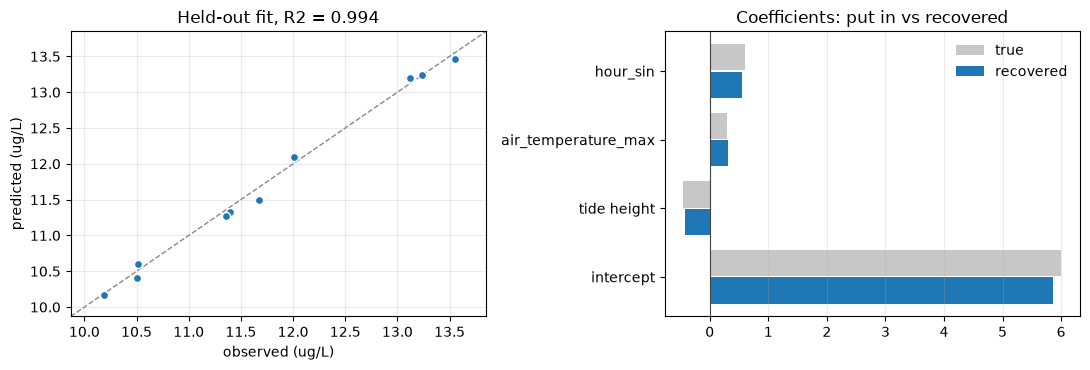

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

ax1.scatter(y_te, predicted, s=34, color="#1f77b4", edgecolor="white", zorder=3)
lims = [min(y_te.min(), predicted.min()) - 0.3, max(y_te.max(), predicted.max()) + 0.3]
ax1.plot(lims, lims, "--", color="#888", lw=1)
ax1.set(xlabel="observed (ug/L)", ylabel="predicted (ug/L)", xlim=lims, ylim=lims,
        title=f"Held-out fit, R2 = {r2_score(y_te, predicted):.3f}")
ax1.grid(alpha=0.25)

pos = np.arange(len(recovery))
ax2.barh(pos + 0.2, recovery["true"], height=0.38, label="true", color="#c7c7c7")
ax2.barh(pos - 0.2, recovery["fitted"], height=0.38, label="recovered", color="#1f77b4")
ax2.set_yticks(pos, [i.replace("water_surface_height_above_reference_datum", "tide height")
                     for i in recovery.index])
ax2.axvline(0, color="#444", lw=0.8)
ax2.set_title("Coefficients: put in vs recovered")
ax2.legend(frameon=False)
ax2.grid(alpha=0.25, axis="x")
fig.tight_layout()

The recovered coefficients land on the ones we put in. Since the truth was constructed without
touching `align()`, that agreement is evidence about the **join**: the timestamps, the units, the
local-date handling and the interval semantics are all right.

## 12. What do I cite?

Attribution comes out of the result rather than out of memory — including what went *wrong*,
which is the part that gets skipped when writing up from notes.

In [25]:
print(omnisea.citation(tree))

Data were retrieved with omnisea 0.1.0 on 2026-08-27T21:30:55+00:00 from 2 source(s) across 2 station(s), covering 2024-07-01 to 2024-07-08.

  Fisheries and Oceans Canada / Canadian Hydrographic Service — dfo_tides (1 station(s), 2024-07-01 to 2024-07-08): Bamfield (08545). Licence: Fisheries and Oceans Canada — Open Government Licence – Canada. Terms: https://open.canada.ca/en/open-government-licence-canada
  Environment and Climate Change Canada / Meteorological Service of Canada — eccc_climate_daily (1 station(s), 2024-07-01 to 2024-07-08): CAPE BEALE LIGHT (1031316). Licence: Environment and Climate Change Canada — Open Government Licence – Canada. Terms: https://eccc-msc.github.io/open-data/licence/readme_en/

  NOTE: a source could not cover the requested window: eccc_ahccd_annual: covers 1840-01-01 to 2020-12-31; the requested window starts 2024-07-01, after the last data this collection publishes; eccc_ahccd_monthly: covers 1840-01-01 to 2020-12-31; the requested window starts

In [26]:
omnisea.provenance(tree)[["provider", "source", "institution", "license", "n_stations", "n_values"]]

,provider,source,institution,license,n_stations,n_values
0,dfo,dfo_tides,Fisheries and Oceans Canada / Canadian Hydrogr...,Fisheries and Oceans Canada — Open Government ...,1,699
1,eccc,eccc_climate_daily,Environment and Climate Change Canada / Meteor...,Environment and Climate Change Canada — Open G...,1,8


## 13. Save it, and pick it up later

The tree round-trips losslessly to netCDF groups — including the per-variable CF attributes that
`align()` reads, so a reopened file resamples exactly the same way.

In [27]:
omnisea.to_netcdf(tree, "bamfield.nc")

import xarray as xr

reopened = xr.open_datatree("bamfield.nc")
again = omnisea.align(reopened, on=field_sheet, tolerance="30min")

same = np.allclose(
    again["air_temperature_max"].to_numpy(),
    X["air_temperature_max"].to_numpy(),
    equal_nan=True,
)
print(f"nodes round-tripped     {len([n for n in reopened.subtree if n.dataset.data_vars])}")
print(f"align() gives the same  {same}")
print(f"citation identical      {omnisea.citation(reopened) == omnisea.citation(tree)}")

nodes round-tripped     3


align() gives the same  True
citation identical      True


## What to take away

Eight sources answered one query. Two of them ended up in the model, joined onto irregular
field-sheet timestamps, pruned of duplicates, and cited — and the coefficients came back.

The parts that are easy to miss are the ones worth remembering:

| | |
|---|---|
| **Discovery is separate** | An innocent-looking bbox can be 276 million rows. You see the estimate first. |
| **Nothing is silently rescaled** | Values stay in provider units, with the units beside them. `to_cf_units=True` is opt-in. |
| **Nothing is silently dropped** | Unmapped fields travel under the provider's own name; QC flags come along. |
| **Resampling is derived, not guessed** | CF `cell_methods` decides. Sums stay sums, extremes stay extremes, bearings are combined as vectors. |
| **Local-date sources are read in the station's zone** | Otherwise every afternoon sample gets tomorrow's weather. |
| **Empty results explain themselves** | "No station here" and "that collection only keeps 30 days" are different answers. |
| **Attribution is derived from the result** | Including the failures, so a partial pull cannot be published as a whole one. |

**Next:** [`docs/adding-a-provider.md`](../docs/adding-a-provider.md) is the contract for adding
a source — one new file, and `python -m omnisea.conformance` checks your work.